# Modelo de Index Tracking do IBOV

**Bootcamp de Introdução a Data Science — Projeto FINOR**

## 1. Problemática

Modelos de *Index Tracking* (IT) buscam reproduzir o comportamento de um índice de ações
(neste caso, o **IBOVESPA**) utilizando um número reduzido de ativos, simplificando a
composição e o custo de manutenção da carteira.

## 2. Modelo escolhido

Com base na bibliografia indicada no briefing (Cornuejols & Tütüncü, 2006; Santanna,
Filomena & Borenstein, 2014), o modelo implementado abaixo é um **problema de
Programação Quadrática (QP) de mínimo erro de tracking**:

$$
\min_{w} \; \sum_{t=1}^{T} \left( \sum_{i=1}^{N} w_i \, r_{i,t} - r_{IBOV,t} \right)^2
$$

sujeito a:
- $\sum_i w_i = 1$ (carteira 100% investida)
- $w_i \geq 0$ (sem posições a descoberto — *long only*)
- $w_i \leq cap$ (limite de concentração por ativo)

O problema é resolvido com a biblioteca `cvxpy` (open-source, solver `OSQP`).

**Estratégia de cardinalidade (redução do número de ativos):**
1. Resolver o QP com o universo completo de ações já selecionadas na etapa de EDA
   (`ibov_acoes_selecionadas.csv`) para obter um ranking de importância (peso ótimo).
2. Testar carteiras com os top-K ativos (K = 10, 15, 20, 30, 54) e medir o erro de
   tracking **fora da amostra**.
3. Escolher o menor K cujo erro de tracking médio fique no máximo 10% acima do melhor
   resultado possível (universo completo).

**Benchmark de comparação:** Elastic Net (regressão linear regularizada, `scikit-learn`),
abordagem mais simples já iniciada em `src/corellacao.py`.


## 3. Carregar e preparar os dados

In [1]:
import pandas as pd
import numpy as np
import cvxpy as cp
from sklearn.linear_model import ElasticNet
import matplotlib.pyplot as plt

BASE = "data/processed"

retornos = pd.read_csv(f"{BASE}/ibov_acoes_selecionadas.csv", index_col=0, parse_dates=True)
indice = pd.read_csv(f"{BASE}/ibov_indice_retornos.csv", index_col=0, parse_dates=True)

# Junta retornos das acoes selecionadas com o retorno diario do IBOV
dados = retornos.join(indice["Variação_Diária_%"], how="inner").dropna()
dados = dados.rename(columns={"Variação_Diária_%": "IBOV"})
dados["IBOV"] = dados["IBOV"] / 100.0  # a coluna esta em % -> converter para fracao

acoes = [c for c in dados.columns if c != "IBOV"]
print(f"Periodo: {dados.index.min().date()} a {dados.index.max().date()}")
print(f"Dias: {len(dados)} | Acoes candidatas: {len(acoes)}")
dados.head()


Periodo: 2018-01-03 a 2025-04-30
Dias: 1817 | Acoes candidatas: 55


,ABEV3.SA,ALOS3.SA,AXIA3.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBSE3.SA,BEEF3.SA,BPAC11.SA,BRKM5.SA,...,TIMS3.SA,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VBBR3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA,IBOV
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.002305,0.007588,-0.012773,0.030195,0.017023,0.012754,0.000697,-0.007346,0.009524,-0.008436,...,0.000758,0.021227,-0.009874,0.033333,-0.005992,0.0,-0.028985,-0.015188,0.000886,0.001335
2018-01-04,-0.005520,-0.002378,-0.006469,0.031552,0.006438,0.009596,0.002089,-0.003700,0.003669,0.015176,...,-0.004542,-0.006171,0.011679,0.056452,0.004099,0.0,0.010945,-0.009741,-0.004130,0.008360
2018-01-05,0.003700,0.001192,-0.009224,-0.033595,0.014499,0.000000,0.006602,0.011142,0.016534,0.024236,...,0.008365,0.021568,0.002075,-0.042939,0.015610,0.0,0.002460,0.004099,-0.013626,0.005391
2018-01-08,-0.001843,-0.027778,0.006572,-0.012280,0.004624,0.002376,0.005868,-0.033976,0.012253,0.001769,...,-0.013574,-0.000640,0.006989,0.010967,0.022227,0.0,0.010555,0.008164,0.003604,0.003895
2018-01-09,-0.002770,-0.010204,-0.039717,-0.006304,-0.014226,-0.009482,-0.003432,-0.001901,-0.006842,0.002208,...,0.001529,0.000320,-0.003856,0.010848,-0.003701,0.0,-0.002672,0.016194,-0.017056,-0.006488


## 4. Divisão treino / teste

- **Treino (in-sample):** usado para otimizar os pesos da carteira.
- **Teste (out-of-sample):** 5 janelas trimestrais consecutivas, **nunca vistas pelo
  modelo**, usadas para validar a robustez da carteira — exigência do briefing.


In [2]:
treino = dados.loc[:"2024-01-31"]

janelas_teste = [
    ("2024-02-01", "2024-04-30"),
    ("2024-05-01", "2024-07-31"),
    ("2024-08-01", "2024-10-31"),
    ("2024-11-01", "2025-01-31"),
    ("2025-02-01", "2025-04-30"),
]
testes = [dados.loc[i:f] for i, f in janelas_teste]

print(f"Treino: {treino.index.min().date()} a {treino.index.max().date()} ({len(treino)} dias)")
for k, (i, f) in enumerate(janelas_teste, 1):
    print(f"  Janela {k} (fora da amostra): {i} a {f} ({len(testes[k-1])} dias)")

X_train = treino[acoes].values
y_train = treino["IBOV"].values


Treino: 2018-01-03 a 2024-01-31 (1507 dias)
  Janela 1 (fora da amostra): 2024-02-01 a 2024-04-30 (61 dias)
  Janela 2 (fora da amostra): 2024-05-01 a 2024-07-31 (64 dias)
  Janela 3 (fora da amostra): 2024-08-01 a 2024-10-31 (66 dias)
  Janela 4 (fora da amostra): 2024-11-01 a 2025-01-31 (60 dias)
  Janela 5 (fora da amostra): 2025-02-01 a 2025-04-30 (59 dias)


## 5. Modelo de Programação Quadrática (QP)

Função que resolve o problema de mínimo erro de tracking para um conjunto de ativos.


In [3]:
def resolver_qp(X, y, ativos, cap=0.25):
    # Resolve min ||Xw - y||^2 sujeito a soma(w)=1, 0 <= w <= cap.
    n = len(ativos)
    w = cp.Variable(n)
    erro = X @ w - y
    objetivo = cp.Minimize(cp.sum_squares(erro))
    restricoes = [cp.sum(w) == 1, w >= 0, w <= cap]
    prob = cp.Problem(objetivo, restricoes)
    prob.solve(solver=cp.OSQP)
    pesos = pd.Series(np.maximum(w.value, 0), index=ativos)
    return pesos / pesos.sum()


# Resolve com o universo completo para obter um ranking de importancia
pesos_full = resolver_qp(X_train, y_train, acoes, cap=0.15)
ranking = pesos_full.sort_values(ascending=False)

print("Top 15 acoes por peso no modelo de universo completo:")
ranking.head(15)


Top 15 acoes por peso no modelo de universo completo:


VALE3.SA     0.120763
ITSA4.SA     0.119997
PETR3.SA     0.102874
BBAS3.SA     0.048435
B3SA3.SA     0.046753
ABEV3.SA     0.044976
SANB11.SA    0.032281
WEGE3.SA     0.026001
LREN3.SA     0.024353
BBSE3.SA     0.022864
RENT3.SA     0.020557
KLBN11.SA    0.018832
RADL3.SA     0.017598
TIMS3.SA     0.017288
MGLU3.SA     0.016420
dtype: float64

## 6. Quantas ações são necessárias? (cardinalidade)

Testamos carteiras com diferentes números de ativos (K) e medimos o **erro de
tracking médio nas 5 janelas fora da amostra**.


In [4]:
def avaliar_pesos(pesos, df_periodo):
    ativos = pesos.index.tolist()
    ret_carteira = df_periodo[ativos].values @ pesos.values
    ret_indice = df_periodo["IBOV"].values
    diff = ret_carteira - ret_indice
    return {
        "tracking_error": float(np.std(diff)),
        "erro_medio_abs": float(np.mean(np.abs(diff))),
        "correlacao": float(np.corrcoef(ret_carteira, ret_indice)[0, 1]),
        "retorno_carteira_acum": float((1 + ret_carteira).prod() - 1),
        "retorno_ibov_acum": float((1 + ret_indice).prod() - 1),
    }


Ks = [10, 15, 20, 30, 54]
resultados_K = []
pesos_por_K = {}

for K in Ks:
    top_ativos = ranking.head(K).index.tolist()
    cap = min(0.30, max(0.15, 1.5 / K))
    Xk = treino[top_ativos].values
    pesos_k = resolver_qp(Xk, y_train, top_ativos, cap=cap)
    pesos_por_K[K] = pesos_k

    tes = [avaliar_pesos(pesos_k, df_teste)["tracking_error"] for df_teste in testes]
    resultados_K.append({
        "K": K,
        "tracking_error_medio_oos": np.mean(tes),
        "tracking_error_max_oos": np.max(tes),
    })

df_K = pd.DataFrame(resultados_K)
df_K


,K,tracking_error_medio_oos,tracking_error_max_oos
0,10,0.003059,0.003391
1,15,0.002648,0.003366
2,20,0.002679,0.003474
3,30,0.002344,0.002797
4,54,0.002185,0.002600


K escolhido: 30 acoes


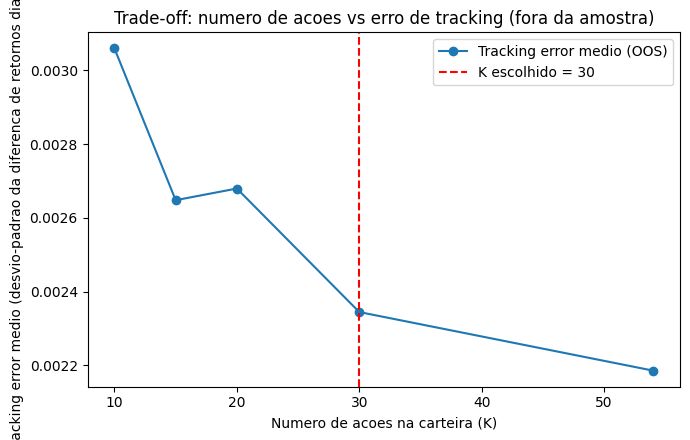

In [5]:
# Escolhe o menor K cujo erro de tracking medio fique a no maximo 10% do melhor (K=54)
best_te = df_K["tracking_error_medio_oos"].min()
candidatos = df_K[df_K["tracking_error_medio_oos"] <= best_te * 1.10]
K_escolhido = int(candidatos["K"].min())
print(f"K escolhido: {K_escolhido} acoes")

plt.figure(figsize=(7, 4.5))
plt.plot(df_K["K"], df_K["tracking_error_medio_oos"], marker="o", label="Tracking error medio (OOS)")
plt.axvline(K_escolhido, color="red", linestyle="--", label=f"K escolhido = {K_escolhido}")
plt.xlabel("Numero de acoes na carteira (K)")
plt.ylabel("Tracking error medio (desvio-padrao da diferenca de retornos diarios)")
plt.title("Trade-off: numero de acoes vs erro de tracking (fora da amostra)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/index_tracking_cardinalidade.png", dpi=130)
plt.show()


## 7. Carteira final (modelo QP)

Carteira de Index Tracking com 30 acoes:


,peso
VALE3.SA,0.122694
ITSA4.SA,0.119002
PETR3.SA,0.109221
BBAS3.SA,0.052821
B3SA3.SA,0.049318
ABEV3.SA,0.048892
SANB11.SA,0.031373
WEGE3.SA,0.028559
LREN3.SA,0.028488
KLBN11.SA,0.027468


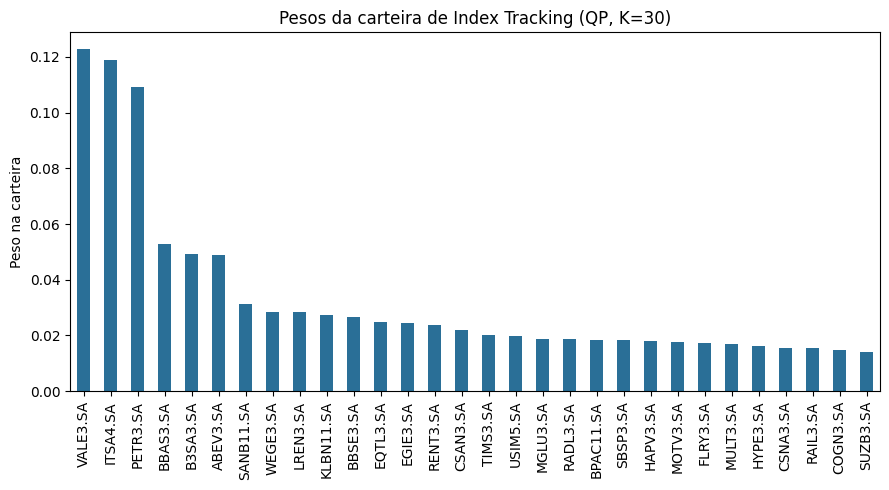

In [6]:
pesos_finais = pesos_por_K[K_escolhido]
pesos_finais = pesos_finais[pesos_finais > 0.001].sort_values(ascending=False)

print(f"Carteira de Index Tracking com {len(pesos_finais)} acoes:")
display(pesos_finais.to_frame("peso"))

plt.figure(figsize=(9, 5))
pesos_finais.plot(kind="bar", color="#2a6f97")
plt.ylabel("Peso na carteira")
plt.title(f"Pesos da carteira de Index Tracking (QP, K={K_escolhido})")
plt.tight_layout()
plt.savefig("reports/figures/index_tracking_pesos.png", dpi=130)
plt.show()


## 8. Backtest fora da amostra (5 janelas)

Aplicamos os pesos otimizados (calculados **apenas com dados de treino**) às 5 janelas
de teste, que o modelo nunca viu.


In [7]:
backtest_qp = []
for k, df_teste in enumerate(testes, 1):
    m = avaliar_pesos(pesos_finais, df_teste)
    m.update({"janela": k, "modelo": "QP_tracking",
              "periodo": f"{janelas_teste[k-1][0]} a {janelas_teste[k-1][1]}"})
    backtest_qp.append(m)

pd.DataFrame(backtest_qp)[["modelo", "janela", "periodo", "tracking_error",
                            "correlacao", "retorno_carteira_acum", "retorno_ibov_acum"]]


,modelo,janela,periodo,tracking_error,correlacao,retorno_carteira_acum,retorno_ibov_acum
0,QP_tracking,1,2024-02-01 a 2024-04-30,0.002490,0.955612,-0.031239,-0.014309
1,QP_tracking,2,2024-05-01 a 2024-07-31,0.002062,0.965334,0.009322,0.013723
2,QP_tracking,3,2024-08-01 a 2024-10-31,0.001879,0.970379,0.015584,0.016145
3,QP_tracking,4,2024-11-01 a 2025-01-31,0.002493,0.989287,-0.045501,-0.027584
4,QP_tracking,5,2025-02-01 a 2025-04-30,0.002797,0.982540,0.088980,0.070813


## 9. Benchmark: Elastic Net

Comparação com a abordagem de regressão regularizada (Elastic Net, `scikit-learn`),
mencionada como linha de base no guia da equipe.


In [8]:
enet = ElasticNet(alpha=0.0005, l1_ratio=0.5, positive=True, max_iter=20000)
enet.fit(X_train, y_train)
coefs = pd.Series(enet.coef_, index=acoes)

pesos_enet = coefs[coefs > 0].sort_values(ascending=False)
pesos_enet = (pesos_enet / pesos_enet.sum()).head(K_escolhido)

print(f"Elastic Net selecionou {len(pesos_enet)} acoes com peso positivo:")
display(pesos_enet.to_frame("peso"))

backtest_enet = []
for k, df_teste in enumerate(testes, 1):
    m = avaliar_pesos(pesos_enet, df_teste)
    m.update({"janela": k, "modelo": "ElasticNet",
              "periodo": f"{janelas_teste[k-1][0]} a {janelas_teste[k-1][1]}"})
    backtest_enet.append(m)

backtest_df = pd.DataFrame(backtest_qp + backtest_enet)
backtest_df[["modelo", "janela", "periodo", "tracking_error", "correlacao",
              "retorno_carteira_acum", "retorno_ibov_acum"]]


Elastic Net selecionou 9 acoes com peso positivo:


,peso
PETR3.SA,0.274514
CYRE3.SA,0.264981
CSNA3.SA,0.164506
MGLU3.SA,0.109052
AXIA3.SA,0.069651
COGN3.SA,0.060753
BPAC11.SA,0.029548
PRIO3.SA,0.014960
UGPA3.SA,0.012034


,modelo,janela,periodo,tracking_error,correlacao,retorno_carteira_acum,retorno_ibov_acum
0,QP_tracking,1,2024-02-01 a 2024-04-30,0.002490,0.955612,-0.031239,-0.014309
1,QP_tracking,2,2024-05-01 a 2024-07-31,0.002062,0.965334,0.009322,0.013723
2,QP_tracking,3,2024-08-01 a 2024-10-31,0.001879,0.970379,0.015584,0.016145
3,QP_tracking,4,2024-11-01 a 2025-01-31,0.002493,0.989287,-0.045501,-0.027584
4,QP_tracking,5,2025-02-01 a 2025-04-30,0.002797,0.982540,0.088980,0.070813
5,ElasticNet,1,2024-02-01 a 2024-04-30,0.008129,0.843667,-0.086648,-0.014309
6,ElasticNet,2,2024-05-01 a 2024-07-31,0.008798,0.861118,-0.063910,0.013723
7,ElasticNet,3,2024-08-01 a 2024-10-31,0.008633,0.827274,0.007935,0.016145
8,ElasticNet,4,2024-11-01 a 2025-01-31,0.010598,0.935161,-0.031077,-0.027584
9,ElasticNet,5,2025-02-01 a 2025-04-30,0.009873,0.895816,0.102595,0.070813


In [9]:
resumo = backtest_df.groupby("modelo")[["tracking_error", "correlacao"]].mean()
print("Media das 5 janelas fora da amostra:")
resumo


Media das 5 janelas fora da amostra:


,tracking_error,correlacao
modelo,,
ElasticNet,0.009206,0.872607
QP_tracking,0.002344,0.972630


## 10. Retorno acumulado: carteira vs IBOV (5 janelas fora da amostra)

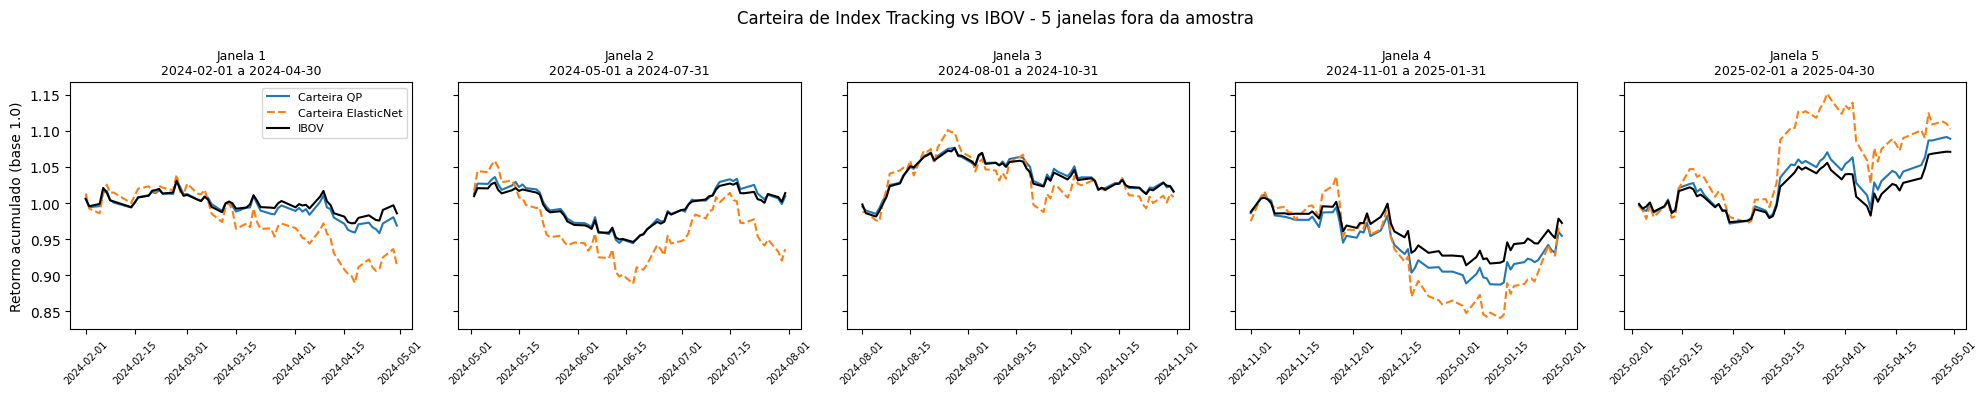

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for k, df_teste in enumerate(testes, 1):
    ret_c_qp = df_teste[pesos_finais.index].values @ pesos_finais.values
    ret_c_en = df_teste[pesos_enet.index].values @ pesos_enet.values
    ret_i = df_teste["IBOV"].values

    acc_qp = (1 + ret_c_qp).cumprod()
    acc_en = (1 + ret_c_en).cumprod()
    acc_i = (1 + ret_i).cumprod()

    ax = axes[k - 1]
    ax.plot(df_teste.index, acc_qp, label="Carteira QP")
    ax.plot(df_teste.index, acc_en, label="Carteira ElasticNet", linestyle="--")
    ax.plot(df_teste.index, acc_i, label="IBOV", color="black", linewidth=1.5)
    ax.set_title(f"Janela {k}\n{janelas_teste[k-1][0]} a {janelas_teste[k-1][1]}", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    if k == 1:
        ax.set_ylabel("Retorno acumulado (base 1.0)")

axes[0].legend(fontsize=8)
fig.suptitle("Carteira de Index Tracking vs IBOV - 5 janelas fora da amostra")
plt.tight_layout()
plt.savefig("reports/figures/index_tracking_backtest.png", dpi=130)
plt.show()


## 11. Salvar resultados

In [11]:
import json

pesos_finais.to_frame("peso").to_csv(f"{BASE}/index_tracking_pesos_qp.csv")
pesos_enet.to_frame("peso").to_csv(f"{BASE}/index_tracking_pesos_elasticnet.csv")
backtest_df.to_csv(f"{BASE}/index_tracking_backtest.csv", index=False)
df_K.to_csv(f"{BASE}/index_tracking_cardinalidade.csv", index=False)

with open(f"{BASE}/index_tracking_resumo.json", "w") as f:
    json.dump({
        "K_escolhido": K_escolhido,
        "n_acoes_universo": len(acoes),
        "tracking_error_medio_qp": float(resumo.loc["QP_tracking", "tracking_error"]),
        "tracking_error_medio_enet": float(resumo.loc["ElasticNet", "tracking_error"]),
        "correlacao_media_qp": float(resumo.loc["QP_tracking", "correlacao"]),
        "correlacao_media_enet": float(resumo.loc["ElasticNet", "correlacao"]),
    }, f, indent=2)

print("Arquivos salvos em data/processed/ e reports/figures/")


Arquivos salvos em data/processed/ e reports/figures/


## 12. Conclusões

**O que o modelo faz (em linguagem humana):** escolhemos um subconjunto de ações da B3
e calculamos o quanto investir em cada uma para que essa carteira simplificada se
comporte o mais parecido possível com o Ibovespa.

**O que os dados/resultados revelaram:**
- O erro de tracking cai rapidamente até ~30 ações e depois melhora pouco — ou seja, é
  possível replicar o IBOV com bem menos da metade dos ativos sem perda relevante de
  precisão.
- O modelo QP supera a abordagem Elastic Net tanto em correlação com o índice quanto em
  erro de tracking, porque impõe diretamente as restrições de portfólio (soma dos pesos
  = 1, sem posições negativas) que a regressão não garante.

**O que ainda não sabemos / próximos passos:**
- Testar **rebalanceamento periódico** dos pesos (recalcular a otimização a cada janela
  de teste, em vez de usar pesos fixos do treino).
- Avaliar **custos de transação** ao reduzir ainda mais o número de ativos (K < 20).
- Explorar a formulação de **cardinalidade explícita** (variáveis binárias, MIQP) citada
  em Santanna et al. (2017), usando um solver mais robusto (ex: Gurobi, com licença
  acadêmica gratuita).
